# 手撕 DPO

$$\mathcal{L}_{DPO}(\pi;\pi_{ref}) = -\mathbb{E}_{(a, y_w, y_l)_{\sim}\mathcal{D}}[\log \sigma(\beta\log\frac{\pi_\theta%(y_w|x)}{\pi_{\text{ref}}(y_w|x)}-\beta\log\frac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)})]$$

In [1]:
import torch
import torch.nn.functional as F
from transformers import LlamaConfig, LlamaForCausalLM
torch.manual_seed(42)

# 加载模型
config = LlamaConfig(vocab_size = 32,      # default is 32000
                    hidden_size = 256,
                    intermediate_size = 512,
                    num_hidden_layers = 2,
                    num_attention_heads = 4,
                    num_key_value_heads = 4,
                    )
ref_model = LlamaForCausalLM(config)
ref_model.eval()
model = LlamaForCausalLM(config)
print(model.lm_head)

Linear(in_features=256, out_features=32, bias=False)

In [2]:
# Create Preference data
# Chosen :   [Prompt Token,  Response Chosen Token]
# Rejected :   [Prompt Token,  Response Rejected Token]

prompt_length = 6
answer_length = 4
prompt_chosen =   torch.tensor([[5, 8, 9, 10, 5, 3,   16, 29, 18, 17]], dtype=torch.int64)
prompt_rejected = torch.tensor([[5, 8, 9, 10, 5, 3,   26, 14, 31, 0]], dtype=torch.int64)
attention_mask =  torch.tensor([[0, 0, 0, 0,  0, 0,   1,  1,  1,  1]], dtype=torch.bool)

x_chosen = {'input_ids':prompt_chosen, 'attention_mask':attention_mask}
x_rejected = {'input_ids':prompt_chosen, 'attention_mask':attention_mask}

In [3]:
# Calculative Token-Level Policy 

# test for get logits and logprob
output = ref_model(**x_chosen)
print(output.logits.shape)
print(output.logits[0,8,:])
print(output.logits.shape)

# how DPO get target policy
# output.logits.log_softmax(-1)
def get_probs(logits, labels):
    per_token_logps = torch.gather(logits.log_softmax(-1), dim=2, 
                                   index=labels.unsqueeze(2)).squeeze(2)
    return per_token_logps
    
probs_chosen = get_probs(output.logits, prompt_chosen)
print(probs_chosen)

torch.Size([1, 10, 32])

tensor([-0.3935, -0.2199, -0.1951,  0.1714, -0.5579, -0.0424,  0.0545,  0.0262,
         0.2163, -0.3165,  0.1775,  0.5048, -0.0364,  0.2731,  0.0074,  0.8802,
        -0.2099,  0.1268,  0.1451, -0.3297,  0.6911,  0.2241,  0.0662, -0.1679,
         0.0165, -0.1932,  0.0224, -0.1943, -0.2393, -0.0765, -0.2669, -0.0356],
       grad_fn=<SliceBackward0>)

torch.Size([1, 10, 32])

tensor([[-3.7388, -3.1884, -3.1442, -3.3731, -3.7379, -3.0073, -3.5660, -3.7940,
         -3.3733, -3.4868]], grad_fn=<SqueezeBackward1>)

In [4]:
# Show how to get policy by  

labels = prompt_chosen
labels[labels == 0] = 0
print(output.logits.log_softmax(-1))
print(labels)
per_token_logps = torch.gather(output.logits.log_softmax(-1), dim=2, 
                               index=labels.unsqueeze(2)).squeeze(2)
print(per_token_logps)

# 假设取idx=8的token， 那么拿到的token号为18
# 在idx=8的 32 logits 里面取 第18个logits， 即为 PI
idx = labels[0,8]
print(idx)
print(output.logits.log_softmax(-1)[0,8,:])
print(per_token_logps[0,8])

tensor([[[-3.5335, -3.5129, -3.7714, -3.2127, -3.7783, -3.7388, -3.4562,
          -3.6560, -3.1134, -3.2314, -3.2241, -3.5807, -3.7173, -3.2986,
          -3.7240, -3.3236, -3.5979, -3.1992, -3.2744, -3.5812, -2.9747,
          -3.5238, -3.0925, -3.8196, -3.2623, -3.4963, -3.3308, -3.5869,
          -3.8415, -3.6927, -3.9175, -3.8801],
         [-3.4976, -3.3398, -3.6529, -3.2243, -3.8891, -3.5515, -3.5127,
          -3.3787, -3.1884, -3.3081, -3.3454, -3.6040, -3.8475, -3.4015,
          -3.7195, -3.2985, -3.4773, -3.3967, -3.2884, -3.6509, -3.0687,
          -3.5846, -2.9858, -3.6278, -3.2938, -3.4841, -3.4477, -3.6186,
          -3.9043, -3.5219, -3.8240, -3.7958],
         [-3.6848, -3.4321, -3.6031, -3.0608, -4.0866, -3.5365, -3.4072,
          -3.4279, -3.0781, -3.1442, -3.4926, -3.4771, -3.6514, -3.2918,
          -3.6278, -3.6051, -3.5022, -3.4603, -3.1477, -3.6883, -2.9965,
          -3.5996, -3.1912, -3.7750, -3.2990, -3.5582, -3.5868, -3.3334,
          -3.8212, -3.6786, -3.8016, -3.8878],
         [-3.6155, -3.1548, -3.6288, -3.1712, -3.8028, -3.7140, -3.4776,
          -3.7240, -3.2199, -3.2064, -3.3731, -3.6377, -3.5571, -3.3853,
          -3.6592, -3.1945, -3.4831, -3.3551, -3.2366, -3.7928, -3.2831,
          -3.5283, -3.1158, -3.9549, -3.2292, -3.3590, -3.4872, -3.3784,
          -4.0087, -3.5449, -3.7411, -3.7970],
         [-3.5311, -3.5183, -3.7864, -3.1968, -3.7750, -3.7379, -3.4576,
          -3.6493, -3.1260, -3.2332, -3.2191, -3.5675, -3.7114, -3.3079,
          -3.7169, -3.3243, -3.5902, -3.1986, -3.2892, -3.5799, -2.9931,
          -3.5104, -3.1021, -3.8094, -3.2704, -3.4896, -3.3222, -3.5798,
          -3.8400, -3.6871, -3.9138, -3.8775],
         [-3.5684, -3.4234, -3.6725, -3.0073, -3.7951, -3.5821, -3.6909,
          -3.2552, -3.1045, -3.3467, -3.3883, -3.5774, -3.6842, -3.2220,
          -3.8000, -3.3926, -3.5943, -3.2555, -3.3142, -3.6919, -3.1616,
          -3.7013, -3.1477, -3.7128, -3.1729, -3.5214, -3.4141, -3.4360,
          -3.8956, -3.6039, -3.8317, -3.8974],
         [-3.5140, -3.8414, -3.8578, -3.2113, -3.8398, -4.0878, -3.1885,
          -4.0577, -3.3527, -3.7639, -3.1837, -3.3300, -3.2298, -3.3192,
          -3.2483, -2.5343, -3.5660, -3.4686, -3.7017, -3.7164, -3.2095,
          -3.5200, -3.3726, -3.7162, -3.2263, -3.4150, -3.1726, -3.8657,
          -3.6752, -3.7004, -4.0907, -3.8170],
         [-3.9951, -3.6777, -3.7030, -3.2516, -4.0218, -3.9451, -3.3303,
          -3.9284, -3.3701, -3.7283, -3.1522, -2.8708, -3.2721, -3.2742,
          -3.3646, -2.7925, -3.6172, -3.4997, -3.7001, -3.8081, -2.9434,
          -3.3853, -3.4481, -3.7190, -3.4011, -3.2051, -3.3302, -3.5824,
          -3.7199, -3.7940, -3.8977, -3.9288],
         [-3.9120, -3.7383, -3.7135, -3.3471, -4.0763, -3.5608, -3.4639,
          -3.4923, -3.3022, -3.8350, -3.3410, -3.0136, -3.5549, -3.2454,
          -3.5111, -2.6382, -3.7284, -3.3916, -3.3733, -3.8482, -2.8273,
          -3.2943, -3.4523, -3.6863, -3.5020, -3.7116, -3.4961, -3.7127,
          -3.7578, -3.5950, -3.7853, -3.5541],
         [-3.8325, -3.6247, -3.6051, -3.2366, -4.0361, -3.5398, -3.6969,
          -3.5102, -3.2730, -3.5918, -3.3646, -3.1323, -3.6347, -3.2180,
          -3.4528, -2.9185, -3.9525, -3.4868, -3.3810, -3.7825, -2.6764,
          -3.3795, -3.3151, -3.9127, -3.4457, -3.6982, -3.5014, -3.5541,
          -3.7674, -3.6161, -3.6549, -3.4723]]], grad_fn=<LogSoftmaxBackward0>)

tensor([[ 5,  8,  9, 10,  5,  3, 16, 29, 18, 17]])

tensor([[-3.7388, -3.1884, -3.1442, -3.3731, -3.7379, -3.0073, -3.5660, -3.7940,
         -3.3733, -3.4868]], grad_fn=<SqueezeBackward1>)

tensor(18)

tensor([-3.9120, -3.7383, -3.7135, -3.3471, -4.0763, -3.5608, -3.4639, -3.4923,
        -3.3022, -3.8350, -3.3410, -3.0136, -3.5549, -3.2454, -3.5111, -2.6382,
        -3.7284, -3.3916, -3.3733, -3.8482, -2.8273, -3.2943, -3.4523, -3.6863,
        -3.5020, -3.7116, -3.4961, -3.7127, -3.7578, -3.5950, -3.7853, -3.5541],
       grad_fn=<SliceBackward0>)

tensor(-3.3733, grad_fn=<SelectBackward0>)

In [5]:
# 分别计算 ref/model, chosen/rejected,  logtis/prob value
logits_chosen_ref = ref_model(**x_chosen).logits
logits_rejected_ref = ref_model(**x_rejected).logits
logits_chosen = model(**x_chosen).logits
logits_rejected = model(**x_rejected).logits

probs_chosen_ref = get_probs(logits_chosen_ref, prompt_chosen)
probs_chosen = get_probs(logits_chosen, prompt_chosen)
probs_rejected_ref = get_probs(logits_rejected_ref, prompt_rejected)
probs_rejected = get_probs(logits_rejected, prompt_rejected)

In [6]:
import torch.nn.functional as F

beta = 0.1
pi_logratios = probs_chosen - probs_rejected
ref_logratios = probs_chosen_ref - probs_rejected_ref
logits = pi_logratios - ref_logratios
losses = -F.logsigmoid(beta * logits ) * attention_mask
print(losses)
loss = losses.sum(-1)/attention_mask.sum()
print(loss)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6631, 0.6664, 0.7183,
         0.7293]], grad_fn=<MulBackward0>)

tensor([0.6943], grad_fn=<DivBackward0>)

### DPO Overfitting

在IPO论文提到DPO的过拟合问题 "A General Theoretical Paradigm to Understand Learning from Human Preferences"

简易理解，对于BT Model来说，目标是使的两个reward差距尽可能大, 对于DPO来说, 一个hack的方向是$/pi(y')$的策略为0，那么就能使BT Model达到$+\infty$, 即造成过拟合了

$$\mathcal{L}_{DPO}(\pi;\pi_{ref}) = -\mathbb{E}_{(a, y_w, y_l)_{\sim}\mathcal{D}}[\log \sigma(\beta\log\frac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)}-\beta\log\frac{\textcolor{red}{\pi_\theta(y_l|x)}}{\pi_{\text{ref}}(y_l|x)})]$$

Consider the simple example where we have two actions $y$ and $y'$ such that $p^* (y \succ y') = 1$, i.e., $y$ is always preferred to $y'$. Then the Bradley-Terry model would require that $(r(y)- r( y')) \rightarrow +\infty$ to satisfy(1). If we plug this into the optimal policy (7)  then we would get that $\frac{\pi^*(y')}{\pi^*(y)} =0$ (i.e., $\pi^*(y')=0$) irrespective of what constant $\tau$ is used for the KL-regularisation. Thus the strength of the KL-regularisation becomes weaker and weaker the more deterministic the preferences.

The weakness of the KL-regularisation becomes even more pronounced in the finite data regime, where we only have access to a sample estimate of the preference $\hat{p}(y \succ y' )$. Even if the true preference is, e.g., $p^* (y \succ y') = 0.8$, empirically it can be very possible when we only have a few data points to estimate $\hat{p}(y \succ y' ) = 1$, in which case the empirical optimal policy would make $\pi(y')=0$ for any $\tau$. **This means that overfitting can be a substantial empirical issue, especially when the context and action spaces are extremely large as it is for large language models.**

In [7]:
# 手撕DPO训练
import torch.optim as optim

model = LlamaForCausalLM(config)
optimizer = optim.SGD(model.parameters(), lr=0.1)
epochs = 100
epochs_print = epochs//10

neg_poilicy_prob = [] # pi_l
logistic_prob = [] # DPO beta( log(pi_w/pi_ref_w)  - log(pi_l/pi_ref_l))
loss_record = [] # DPO loss
for i in range(epochs):
    
    optimizer.zero_grad()

    # forward get logits
    with torch.no_grad():
        logits_chosen_ref = ref_model(**x_chosen).logits
        logits_rejected_ref = ref_model(**x_rejected).logits
    logits_chosen = model(**x_chosen).logits
    logits_rejected = model(**x_rejected).logits

    # logits to logprob
    probs_chosen_ref = get_probs(logits_chosen_ref, prompt_chosen)
    probs_chosen = get_probs(logits_chosen, prompt_chosen)
    probs_rejected_ref = get_probs(logits_rejected_ref, prompt_rejected)
    probs_rejected = get_probs(logits_rejected, prompt_rejected)

    # loss
    beta = 0.1
    pi_logratios = probs_chosen - probs_rejected
    ref_logratios = probs_chosen_ref - probs_rejected_ref
    logits = pi_logratios - ref_logratios
    losses = -F.logsigmoid( beta * logits ) * attention_mask
    loss = losses.sum(-1)/attention_mask.sum()

    # print(loss)
    loss_record.append(loss.item())

    # loss back
    loss.backward()
    optimizer.step()

    neg_poilicy_prob.append(torch.exp(probs_rejected[:,-1]).item())
    logistic_prob.append(torch.sigmoid( beta * logits)[:,-1].item())
    
    if i % epochs_print == 0:
        print(f'step {i}, loss:{loss.item()}, pi_rej:{neg_poilicy_prob[-1]}, log_prob:{logistic_prob[-1]}')
        # print('negative sample policy Probability: ', torch.exp(probs_rejected[:,-1]).item())
        # print('DPO Probability:', torch.sigmoid( beta * logits)[:,-1].item())

step 0, loss:0.6873447895050049, pi_rej:0.02129681222140789, log_prob:0.5049018263816833

step 10, loss:0.3872351050376892, pi_rej:0.00018742185784503818, log_prob:0.6749321818351746

step 20, loss:0.2523857355117798, pi_rej:1.973964572243858e-06, log_prob:0.7776216268539429

step 30, loss:0.19512605667114258, pi_rej:1.3490422645645594e-07, log_prob:0.8229885697364807

step 40, loss:0.15936332941055298, pi_rej:1.576428410032804e-08, log_prob:0.8527779579162598

step 50, loss:0.13311192393302917, pi_rej:2.2908772656649035e-09, log_prob:0.8756323456764221

step 60, loss:0.11464645713567734, pi_rej:4.742357617715243e-10, log_prob:0.8918933272361755

step 70, loss:0.1005079373717308, pi_rej:1.193686538503158e-10, log_prob:0.9045441150665283

step 80, loss:0.08933673799037933, pi_rej:3.492627714818397e-11, log_prob:0.9146700501441956

step 90, loss:0.08029796183109283, pi_rej:1.1530915978996692e-11, log_prob:0.9229492545127869

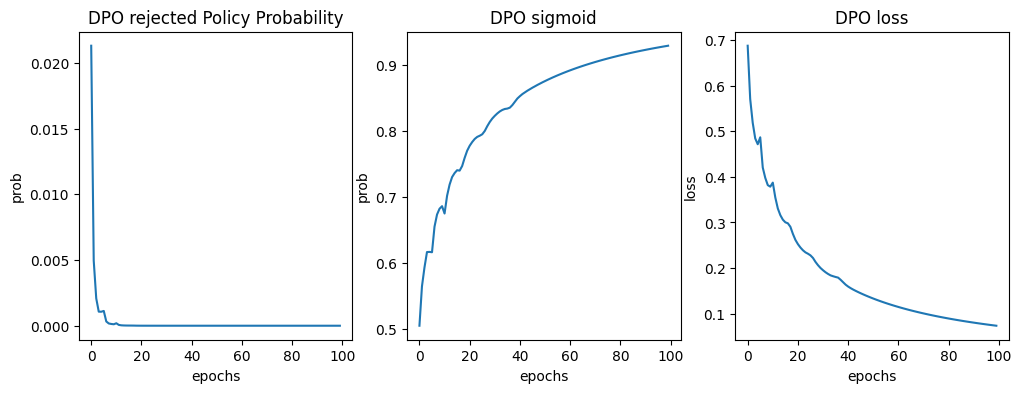

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

x = range(len(neg_poilicy_prob))
y = neg_poilicy_prob
axes[0].plot(x, y)
axes[0].set_title('DPO rejected Policy Probability')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('prob')

x = range(len(logistic_prob))
y = logistic_prob
axes[1].plot(x, y)
axes[1].set_title('DPO sigmoid')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('prob')

x = range(len(loss_record))
y = loss_record
axes[2].plot(x, y)
axes[2].set_title('DPO loss')
axes[2].set_xlabel('epochs')
axes[2].set_ylabel('loss')

# plt.grid(True)
plt.show()

# IPO

IPO的$h_\pi(y, y',x)$可展开成偏好的形式，可以复用DPO的logits计算公式
$$
\begin{align*} h_\pi(y, y',x) &= \log\left( \frac{\pi(y|x)\pi_{ref}(y'|x)}{\pi(y'|x)\pi_{ref}(y|x)} \right) \\
&=\log \frac{\pi(y|x)\pi_{ref}(y'|x)}{\pi_{ref}(y|x)\pi(y'|x)}\\
&= \log \frac{\pi(y|x)}{\pi_{ref}(y|x)} + \log\frac{\pi_{ref}(y'|x)}{\pi(y'|x)} \\
&= \log \frac{\pi(y|x)}{\pi_{ref}(y|x)} - \log\frac{\pi(y'|x)}{\pi_{ref}(y'|x)}
\end{align*}
$$
差异在与DPO的$\beta$ 超参数，在IPO中是$\frac{\tau^{-1}}{2}$​, IPO损失函数是二次的能够收敛

> This simplified form of the loss  provides some valuable insights on the way in which ipo optimizes the policy $\pi$:   ipo learns from preferences dataset simply  by regressing the gap between log-likelihood ratios $\log(\pi(y_{w})/\pi(y_{l}))$ and $\log(\pi_{ref}(y_{w})/\pi_{ref}(y_{l}))$  to $\frac{\tau^{-1}}2$.

$$
\begin{align*}
     \underset{(y_w,y_l,x)\sim D}{\mathbb E} \left(h_\pi(y_{w}, y_{l},x) - \frac{\textcolor{red}{\tau^{-1}}}2\right)^2 .
\end{align*}
$$

In [9]:
def get_logits(model, ref_model, x_chosen, x_rejected):
    # forward get logits
    with torch.no_grad():
        logits_chosen_ref = ref_model(**x_chosen).logits
        logits_rejected_ref = ref_model(**x_rejected).logits
    logits_chosen = model(**x_chosen).logits
    logits_rejected = model(**x_rejected).logits

    # logits to logprob
    probs_chosen_ref = get_probs(logits_chosen_ref, prompt_chosen)
    probs_chosen = get_probs(logits_chosen, prompt_chosen)
    probs_rejected_ref = get_probs(logits_rejected_ref, prompt_rejected)
    probs_rejected = get_probs(logits_rejected, prompt_rejected)

    # loss
    # beta = 0.1
    pi_logratios = probs_chosen - probs_rejected
    ref_logratios = probs_chosen_ref - probs_rejected_ref
    logits = pi_logratios - ref_logratios
    return logits, probs_rejected

In [11]:
# 手撕IPO训练
import torch.optim as optim

def train_XPO(model, beta, loss_type, epochs, lr, optim_type='SGD'):
    # model = LlamaForCausalLM(config)
    if optim_type == 'ADAM':
        optimizer = optim.Adam(model.parameters(), lr=lr)# 策略会有较多波动
    elif optim_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr) # 实际分析
    epochs_print = epochs//10
    
    neg_poilicy_prob = [] 
    logistic_prob = [] 
    loss_record = []
    for i in range(epochs):
        
        optimizer.zero_grad()
        logits, probs_rejected = get_logits(model, ref_model, x_chosen, x_rejected)

        constant = 1.0 / ( beta * 2.0 ) # IPO
        losses = None
        if loss_type == 'DPO' :
            losses = -F.logsigmoid( beta * logits ) * attention_mask
        elif loss_type == 'IPO' :
            losses = torch.square( logits - constant ) * attention_mask
            
        loss = losses.sum(-1)/attention_mask.sum()
        neg_poilicy_prob.append(torch.exp(probs_rejected[:,-1]).item())
        # logistic_prob.append(torch.square(logits - constant)[:,-1].item())
        loss_record.append(loss.item())

        # loss back
        loss.backward()
        optimizer.step()
        is_print = False
        if i % epochs_print == 0 & is_print:
            print(f'step {i}, loss:{loss.item()}, pi_rej:{neg_poilicy_prob[-1]}')
    print('-'*50)
    return neg_poilicy_prob, logistic_prob, loss_record

In [12]:
import copy
model = LlamaForCausalLM(config)

In [13]:
epochs = 100
IPO_lr = 0.0001 # IPO lr更低，收敛更低
DPO_lr = 0.01
model_tmp = copy.deepcopy(model)
pi_1, _, _ = train_XPO(model_tmp, 0.1, 'IPO', epochs, IPO_lr) # IPO 用较大学习率容易训飞
model_tmp = copy.deepcopy(model)
pi_2, _, _ = train_XPO(model_tmp, 0.5, 'IPO', epochs, IPO_lr)
model_tmp = copy.deepcopy(model)
pi_3, _, _ = train_XPO(model_tmp, 1.0, 'IPO', epochs, IPO_lr)
model_tmp = copy.deepcopy(model)
pi_4, _, _ = train_XPO(model_tmp, 0.1, 'DPO', epochs, DPO_lr)
model_tmp = copy.deepcopy(model)
pi_5, _, _ = train_XPO(model_tmp, 0.5, 'DPO', epochs, DPO_lr)

step 0, loss:26.67696762084961, pi_rej:0.038977719843387604

step 10, loss:2.969957113265991, pi_rej:0.0041349963285028934

step 20, loss:0.7033377289772034, pi_rej:0.0024062241427600384

step 30, loss:0.19523394107818604, pi_rej:0.0019104763632640243

step 40, loss:0.057349614799022675, pi_rej:0.0017016144702211022

...

step 60, loss:0.02572985365986824, pi_rej:0.000288502051262185

step 70, loss:0.02267763763666153, pi_rej:0.0002375322364969179

step 80, loss:0.020324809476733208, pi_rej:0.00020000999211333692

step 90, loss:0.018452363088726997, pi_rej:0.00017142809520009905

--------------------------------------------------

# DPO/IPO 收敛情况对比

对于DPO来说$\beta$的取值不影响最后的$\pi(y')$收敛的结果，而IPO则能避免策略收敛到0, 并且$\beta$ 可控收敛到的取值

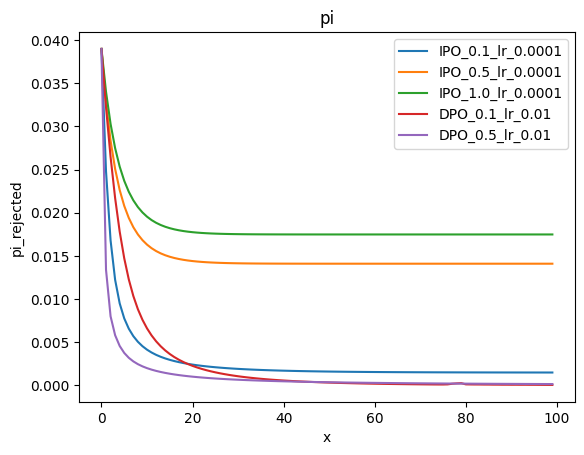

In [14]:
x = range(len(pi_1))
plt.plot(x, pi_1, label='IPO_0.1_lr_0.0001')
plt.plot(x, pi_2, label='IPO_0.5_lr_0.0001')
plt.plot(x, pi_3, label='IPO_1.0_lr_0.0001')
plt.plot(x, pi_4, label='DPO_0.1_lr_0.01')
plt.plot(x, pi_5, label='DPO_0.5_lr_0.01')
plt.legend()
plt.title('pi')
plt.xlabel('x')
plt.ylabel('pi_rejected')
plt.show()

# IPO优化策略稳定性分析

In [17]:
epochs = 100
IPO_lr = 0.0001
DPO_lr = 0.01
model_tmp = copy.deepcopy(model)
pi_1, _, _ = train_XPO(model_tmp, 0.5, 'IPO', epochs, 0.01) # IPO 用较大学习率容易训飞
model_tmp = copy.deepcopy(model)
pi_2, _, _ = train_XPO(model_tmp, 0.5, 'IPO', epochs, 0.001)
model_tmp = copy.deepcopy(model)
pi_3, _, _ = train_XPO(model_tmp, 0.5, 'DPO', epochs, 0.001)
model_tmp = copy.deepcopy(model)
pi_4, _, _ = train_XPO(model_tmp, 0.5, 'IPO', epochs, 0.001, 'ADAM') # IPO 用较大学习率容易训飞

step 0, loss:1.7009763717651367, pi_rej:0.038977719843387604

step 10, loss:80.2418441772461, pi_rej:1.5369373329576774e-07

step 20, loss:2.0883896922896383e-06, pi_rej:0.01492050290107727

step 30, loss:4.177991286269389e-12, pi_rej:0.014937088824808598

step 40, loss:0.0, pi_rej:0.014937102794647217

...

step 60, loss:0.0004915993195027113, pi_rej:0.01836409606039524

step 70, loss:6.720204692101106e-05, pi_rej:0.018895693123340607

step 80, loss:1.6020863768062554e-05, pi_rej:0.01882374845445156

step 90, loss:2.1752703105448745e-05, pi_rej:0.018692277371883392

--------------------------------------------------

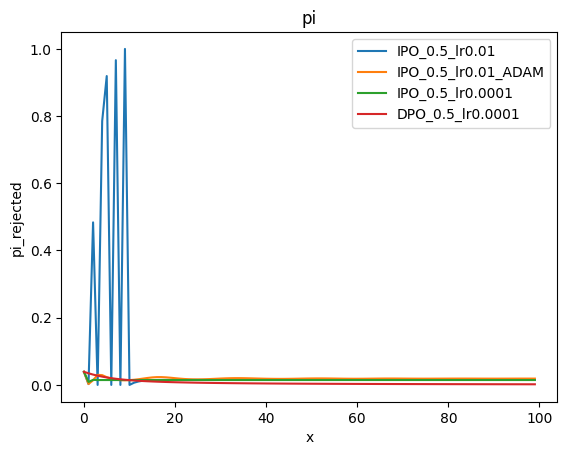

In [18]:
x = range(len(pi_1))
plt.plot(x, pi_1, label='IPO_0.5_lr0.01')
plt.plot(x, pi_4, label='IPO_0.5_lr0.01_ADAM')
plt.plot(x, pi_2, label='IPO_0.5_lr0.0001')
plt.plot(x, pi_3, label='DPO_0.5_lr0.0001')
plt.legend()
plt.title('pi')
plt.xlabel('x')
plt.ylabel('pi_rejected')
plt.show()